# Parent Identification Analysis

**Research Question**: Do causal-aware SHAP methods assign higher importance to true causal parents?

This notebook analyzes:
1. How well each method identifies **true parents** (ground truth causes of Y)
2. How well each method aligns with **discovered parents** (from causal discovery)
3. Comparison of importance assigned to parents vs non-parents

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display, Markdown

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (15, 10)

# Directories
BASE_DIR = Path('/Users/juanrios/Documents/master_thesis')
EXPLAINABILITY_DIR = BASE_DIR / 'data' / 'explainability'

DATASETS = [
    'linear_no_conf_f10_s500_p50',
    'linear_conf_f10_s500_p50',
    'nonlinear_no_conf_f10_s500_p50',
    'nonlinear_conf_f10_s500_p50',
    'mixed_no_conf_f10_s500_p50',
    'mixed_conf_f10_s500_p50'
]

CAUSAL_METHODS = ['pc', 'lingam']
PREDICTIVE_MODELS = ['lgbm', 'nn']
SHAPLEY_METHODS = ['Scratch', 'Asymmetric', 'Causal', 'Flow']

print("✅ Setup complete!")

✅ Setup complete!


## 1. Load Parent Identification Metrics

In [2]:
def load_method_comparison(dataset, model, discovery_method):
    """Load method comparison metrics."""
    comparison_path = EXPLAINABILITY_DIR / dataset / model / discovery_method / 'method_comparison.json'
    if comparison_path.exists():
        with open(comparison_path, 'r') as f:
            return json.load(f)
    return None

# Collect all metrics
parent_metrics = []
for dataset in DATASETS:
    for model in PREDICTIVE_MODELS:
        for causal_method in CAUSAL_METHODS:
            metrics = load_method_comparison(dataset, model, causal_method)
            if metrics:
                for shap_method in SHAPLEY_METHODS:
                    if shap_method in metrics:
                        method_data = metrics[shap_method]
                        parent_metrics.append({
                            'dataset': dataset,
                            'model': model.upper(),
                            'causal_discovery': causal_method.upper(),
                            'shapley_method': shap_method,
                            # True parent metrics
                            'importance_ratio_true': method_data.get('importance_ratio_true_parents'),
                            'mean_shap_true_parents': method_data.get('mean_shap_true_parents'),
                            'mean_shap_non_parents': method_data.get('mean_shap_non_parents'),
                            'true_parents_in_top5': method_data.get('true_parents_in_top5'),
                            'total_true_parents': method_data.get('total_true_parents'),
                            # Discovered parent metrics
                            'importance_ratio_discovered': method_data.get('importance_ratio_discovered_parents'),
                            'mean_shap_discovered': method_data.get('mean_shap_discovered_parents'),
                            'discovered_parents_in_top5': method_data.get('discovered_parents_in_top5'),
                            'total_discovered_parents': method_data.get('total_discovered_parents'),
                            # Reference
                            'true_parent_features': str(method_data.get('true_parent_features')),
                            'discovered_parent_features': str(method_data.get('discovered_parent_features'))
                        })

parent_df = pd.DataFrame(parent_metrics)
print(f"Loaded {len(parent_df)} metric records")
display(parent_df.head(10))

Loaded 96 metric records


,dataset,model,causal_discovery,shapley_method,importance_ratio_true,mean_shap_true_parents,mean_shap_non_parents,true_parents_in_top5,total_true_parents,importance_ratio_discovered,mean_shap_discovered,discovered_parents_in_top5,total_discovered_parents,true_parent_features,discovered_parent_features
0,linear_no_conf_f10_s500_p50,LGBM,PC,Scratch,2.754222,0.553926,0.201119,3,5,0.925412,0.357360,2,3,"[0, 4, 6, 8, 9]","[0, 3, 7]"
1,linear_no_conf_f10_s500_p50,LGBM,PC,Asymmetric,2.682361,0.550316,0.205161,3,5,0.889955,0.347647,2,3,"[0, 4, 6, 8, 9]","[0, 3, 7]"
2,linear_no_conf_f10_s500_p50,LGBM,PC,Causal,3.651834,0.584646,0.160097,3,5,1.157995,0.411691,2,3,"[0, 4, 6, 8, 9]","[0, 3, 7]"
3,linear_no_conf_f10_s500_p50,LGBM,PC,Flow,5.572364,0.898346,0.161215,5,5,0.327606,0.217416,1,3,"[0, 4, 6, 8, 9]","[0, 3, 7]"
4,linear_no_conf_f10_s500_p50,LGBM,LINGAM,Scratch,2.754222,0.553926,0.201119,3,5,0.165088,0.068002,0,1,"[0, 4, 6, 8, 9]",[4]
5,linear_no_conf_f10_s500_p50,LGBM,LINGAM,Asymmetric,2.646753,0.542944,0.205136,3,5,0.155430,0.063500,0,1,"[0, 4, 6, 8, 9]",[4]
6,linear_no_conf_f10_s500_p50,LGBM,LINGAM,Causal,4.826670,0.694161,0.143818,5,5,1.128860,0.466963,1,1,"[0, 4, 6, 8, 9]",[4]
7,linear_no_conf_f10_s500_p50,LGBM,LINGAM,Flow,0.580773,1.254206,2.159547,3,5,0.236934,0.437825,0,1,"[0, 4, 6, 8, 9]",[4]
8,linear_no_conf_f10_s500_p50,NN,PC,Scratch,16.048253,1.395091,0.086931,3,5,0.085982,0.087784,1,3,"[0, 4, 6, 8, 9]","[0, 3, 7]"
9,linear_no_conf_f10_s500_p50,NN,PC,Asymmetric,15.280590,1.370419,0.089684,3,5,0.094235,0.094466,1,3,"[0, 4, 6, 8, 9]","[0, 3, 7]"


## 2. True Parent Identification

**Key Metric**: Importance Ratio = Mean SHAP(Parents) / Mean SHAP(Non-Parents)
- **Ratio > 1**: Method assigns higher importance to true parents ✅
- **Ratio < 1**: Method assigns higher importance to non-parents ❌
- **Ratio ≈ 1**: Method treats parents and non-parents equally

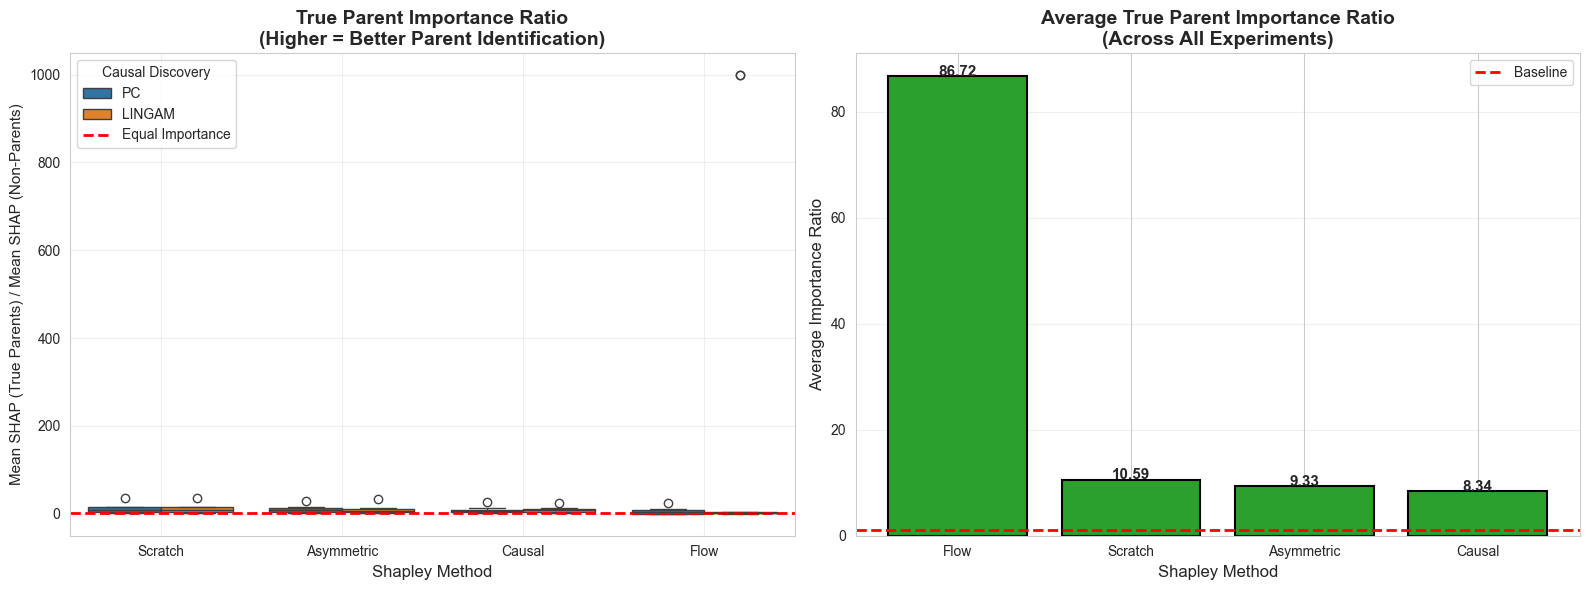


📊 Summary Statistics:
                count       mean         std       min       25%       50%  \
shapley_method                                                               
Asymmetric       24.0   9.327442    8.263416  0.874994  3.737042  7.628954   
Causal           24.0   8.343188    6.342837  1.703621  4.224529  6.217648   
Flow             24.0  86.718670  281.025267  0.120138  0.869450  2.193028   
Scratch          24.0  10.589258    9.367145  1.534115  4.101594  7.573217   

                      75%         max  
shapley_method                         
Asymmetric      12.676064   33.817635  
Causal          11.675991   26.159280  
Flow             5.958440  999.000000  
Scratch         14.414566   35.945589  


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: True Parent Importance Ratio by Method
sns.boxplot(data=parent_df, x='shapley_method', y='importance_ratio_true', 
            hue='causal_discovery', ax=axes[0])
axes[0].set_title('True Parent Importance Ratio\n(Higher = Better Parent Identification)', 
                 fontsize=14, fontweight='bold')
axes[0].set_xlabel('Shapley Method', fontsize=12)
axes[0].set_ylabel('Mean SHAP (True Parents) / Mean SHAP (Non-Parents)', fontsize=11)
axes[0].axhline(y=1, color='red', linestyle='--', linewidth=2, label='Equal Importance')
axes[0].legend(title='Causal Discovery', loc='upper left')
axes[0].grid(alpha=0.3)

# Plot 2: Mean comparison
avg_by_method = parent_df.groupby('shapley_method')['importance_ratio_true'].mean().sort_values(ascending=False)
colors = ['#2ca02c' if x > 1 else '#d62728' for x in avg_by_method.values]
axes[1].bar(avg_by_method.index, avg_by_method.values, color=colors, edgecolor='black', linewidth=1.5)
axes[1].set_title('Average True Parent Importance Ratio\n(Across All Experiments)', 
                 fontsize=14, fontweight='bold')
axes[1].set_xlabel('Shapley Method', fontsize=12)
axes[1].set_ylabel('Average Importance Ratio', fontsize=12)
axes[1].axhline(y=1, color='red', linestyle='--', linewidth=2, label='Baseline')
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')

# Add value labels on bars
for i, (method, value) in enumerate(avg_by_method.items()):
    axes[1].text(i, value + 0.05, f'{value:.2f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📊 Summary Statistics:")
print(parent_df.groupby('shapley_method')['importance_ratio_true'].describe())

## 3. True Parent Recall @ Top-5

**Question**: What proportion of true parents appear in the top-5 most important features?

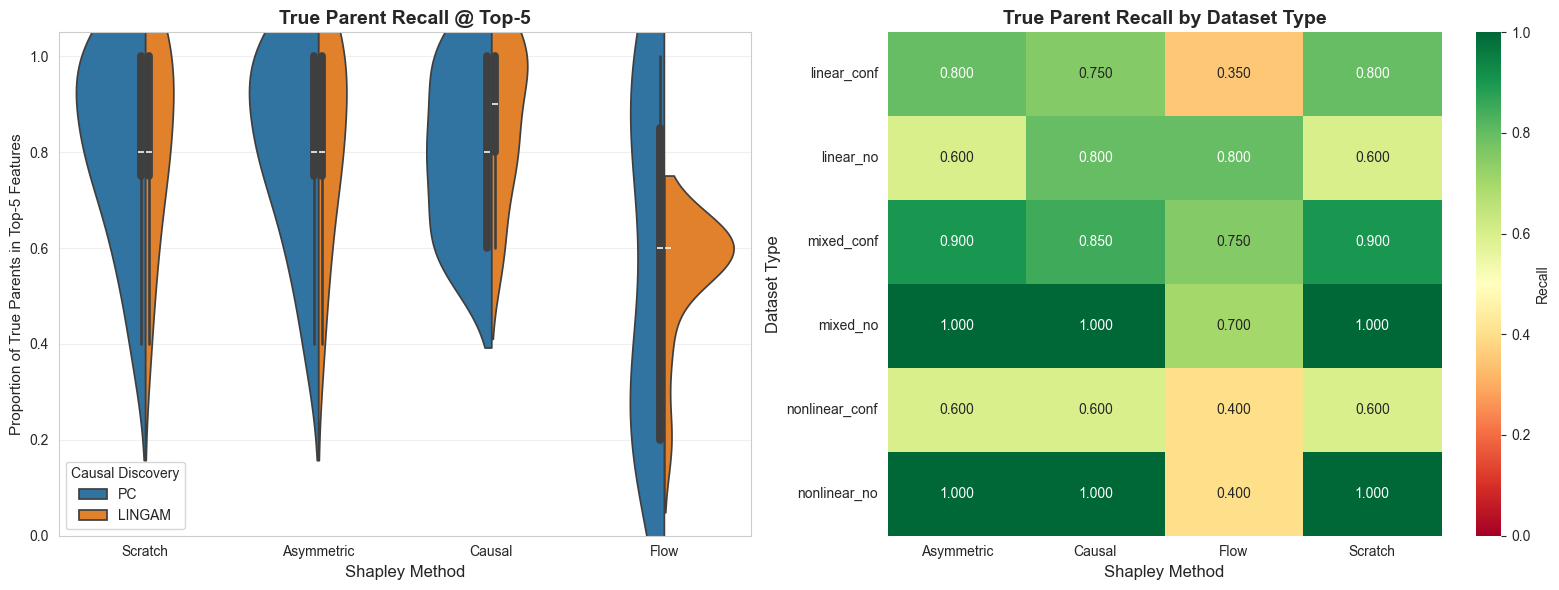

In [4]:
# Calculate recall
parent_df['true_parent_recall'] = parent_df['true_parents_in_top5'] / parent_df['total_true_parents']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Recall distribution
sns.violinplot(data=parent_df, x='shapley_method', y='true_parent_recall', 
               hue='causal_discovery', split=True, ax=axes[0])
axes[0].set_title('True Parent Recall @ Top-5', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Shapley Method', fontsize=12)
axes[0].set_ylabel('Proportion of True Parents in Top-5 Features', fontsize=11)
axes[0].set_ylim([0, 1.05])
axes[0].legend(title='Causal Discovery')
axes[0].grid(alpha=0.3, axis='y')

# Plot 2: Heatmap by dataset type
parent_df['dataset_type'] = parent_df['dataset'].apply(lambda x: x.split('_')[0] + '_' + x.split('_')[1])
recall_pivot = parent_df.pivot_table(
    values='true_parent_recall',
    index='dataset_type',
    columns='shapley_method',
    aggfunc='mean'
)
sns.heatmap(recall_pivot, annot=True, fmt='.3f', cmap='RdYlGn', 
            vmin=0, vmax=1, cbar_kws={'label': 'Recall'}, ax=axes[1])
axes[1].set_title('True Parent Recall by Dataset Type', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Shapley Method', fontsize=12)
axes[1].set_ylabel('Dataset Type', fontsize=12)

plt.tight_layout()
plt.show()

## 4. Discovered Parents Alignment

Do SHAP methods align with the causal structure discovered by PC/LiNGAM?

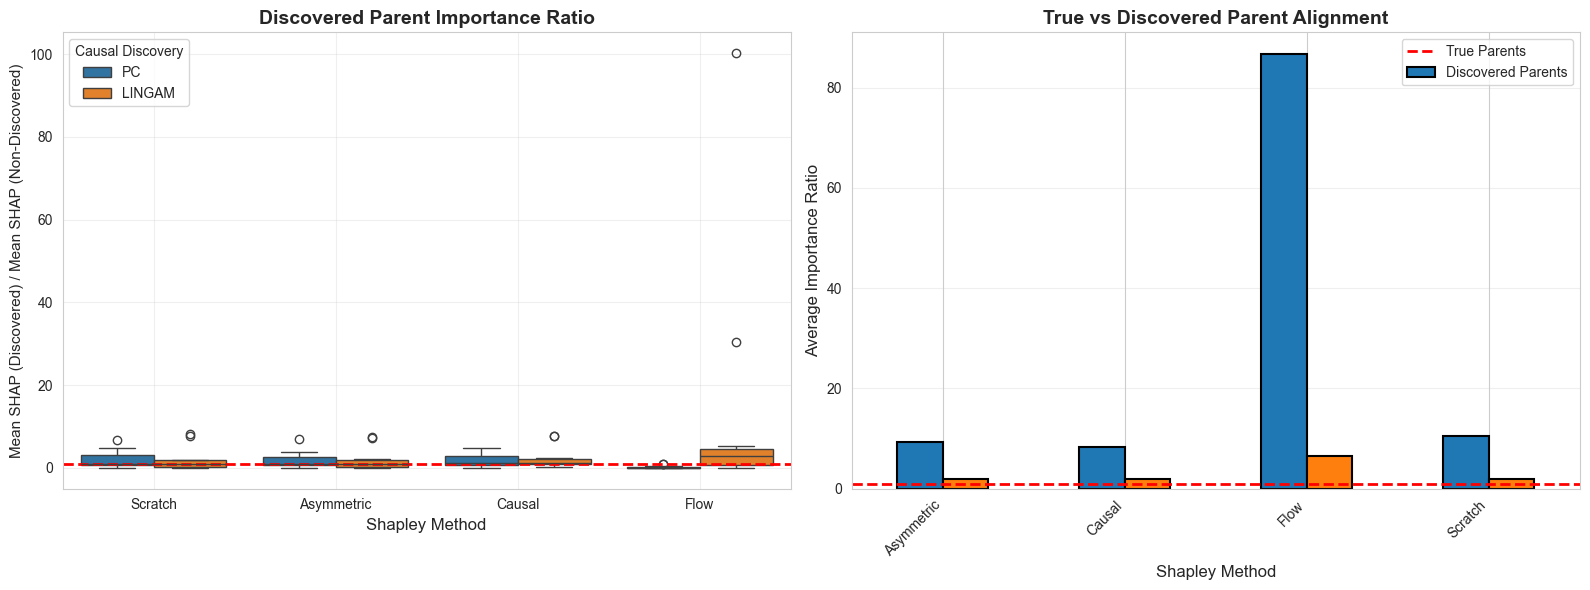

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Discovered parent importance ratio
sns.boxplot(data=parent_df, x='shapley_method', y='importance_ratio_discovered',
            hue='causal_discovery', ax=axes[0])
axes[0].set_title('Discovered Parent Importance Ratio', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Shapley Method', fontsize=12)
axes[0].set_ylabel('Mean SHAP (Discovered) / Mean SHAP (Non-Discovered)', fontsize=11)
axes[0].axhline(y=1, color='red', linestyle='--', linewidth=2)
axes[0].legend(title='Causal Discovery')
axes[0].grid(alpha=0.3)

# Plot 2: Comparison of true vs discovered alignment
comparison = parent_df.groupby('shapley_method')[['importance_ratio_true', 'importance_ratio_discovered']].mean()
comparison.plot(kind='bar', ax=axes[1], color=['#1f77b4', '#ff7f0e'], edgecolor='black', linewidth=1.5)
axes[1].set_title('True vs Discovered Parent Alignment', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Shapley Method', fontsize=12)
axes[1].set_ylabel('Average Importance Ratio', fontsize=12)
axes[1].axhline(y=1, color='red', linestyle='--', linewidth=2)
axes[1].legend(['True Parents', 'Discovered Parents'])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 5. Detailed Method Comparison

In [6]:
# Create summary table
summary = parent_df.groupby('shapley_method').agg({
    'importance_ratio_true': ['mean', 'std', 'median'],
    'true_parent_recall': ['mean', 'std', 'median'],
    'importance_ratio_discovered': ['mean', 'std', 'median']
}).round(3)

display(Markdown("### Summary Statistics by Shapley Method"))
display(summary)

# Statistical test: Are causal methods better than Scratch?
from scipy import stats

scratch_ratios = parent_df[parent_df['shapley_method'] == 'Scratch']['importance_ratio_true']

print("\n🔬 Statistical Tests (vs Scratch):")
for method in ['Asymmetric', 'Causal', 'Flow']:
    method_ratios = parent_df[parent_df['shapley_method'] == method]['importance_ratio_true']
    if len(method_ratios) > 0 and len(scratch_ratios) > 0:
        t_stat, p_value = stats.ttest_ind(method_ratios, scratch_ratios)
        print(f"\n{method}:")
        print(f"  Mean ratio: {method_ratios.mean():.3f} vs Scratch: {scratch_ratios.mean():.3f}")
        print(f"  t-statistic: {t_stat:.3f}, p-value: {p_value:.4f}")
        if p_value < 0.05:
            print(f"  ✅ Significantly different from Scratch (p < 0.05)")
        else:
            print(f"  ❌ Not significantly different from Scratch")

### Summary Statistics by Shapley Method

importance_ratio_true                 true_parent_recall  \
                                mean      std median               mean   
shapley_method                                                            
Asymmetric                     9.327    8.263  7.629              0.817   
Causal                         8.343    6.343  6.218              0.833   
Flow                          86.719  281.025  2.193              0.567   
Scratch                       10.589    9.367  7.573              0.817   

                             importance_ratio_discovered                 
                  std median                        mean     std median  
shapley_method                                                           
Asymmetric      0.195    0.8                       1.882   2.304  0.944  
Causal          0.163    0.8                       1.954   2.124  1.146  
Flow            0.255    0.6                       6.459  20.900  0.282  
Scratch         0.195    0.8                       1.975   2.454  0.957


🔬 Statistical Tests (vs Scratch):

Asymmetric:
  Mean ratio: 9.327 vs Scratch: 10.589
  t-statistic: -0.495, p-value: 0.6230
  ❌ Not significantly different from Scratch

Causal:
  Mean ratio: 8.343 vs Scratch: 10.589
  t-statistic: -0.973, p-value: 0.3358
  ❌ Not significantly different from Scratch

Flow:
  Mean ratio: 86.719 vs Scratch: 10.589
  t-statistic: 1.326, p-value: 0.1913
  ❌ Not significantly different from Scratch


## 6. Export Results for Paper/Thesis

In [7]:
# Save summary statistics
output_dir = BASE_DIR / 'visualizations' / 'parent_analysis_results'
output_dir.mkdir(exist_ok=True)

# Export CSV
parent_df.to_csv(output_dir / 'parent_identification_metrics.csv', index=False)
summary.to_csv(output_dir / 'summary_statistics.csv')

print(f"✅ Results saved to: {output_dir}")
print(f"   - parent_identification_metrics.csv")
print(f"   - summary_statistics.csv")

✅ Results saved to: /Users/juanrios/Documents/master_thesis/visualizations/parent_analysis_results
   - parent_identification_metrics.csv
   - summary_statistics.csv
